# Implement the logistic regression on the attached dataset.

Write your own code.

Report the decision boundary and the accuracy.

Use all the datset given in the dataset and report the accuracy on the same

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
data = pd.read_csv("logistic-regression-data.csv")
data.head()

,X1,X2,class
0,0,1,A
1,1,0,A
2,2,3,A
3,3,1,A
4,2,2,A


In [20]:
A = data[data["class"] == "A"]
B = data[data["class"]=="B"]

In [21]:
A

,X1,X2,class
0,0,1,A
1,1,0,A
2,2,3,A
3,3,1,A
4,2,2,A
5,4,0,A
6,4,3,A
7,3,4,A
8,5,1,A


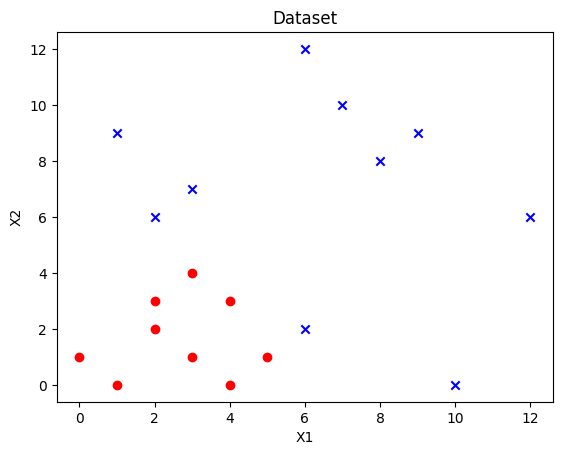

In [22]:
plt.figure()
plt.scatter(A["X1"], A["X2"], marker="o", color="red")
plt.scatter(B["X1"], B["X2"], marker="x", color="blue")
plt.xlabel("X1")
plt.ylabel("X2")

plt.title("Dataset")
plt.show()

# Fitting Logistic regression line

In [23]:
data["y"] = data["class"].map({"A":0, "B":1})

X = data[["X1", "X2"]].values
y = data["y"].values


In [24]:
X = np.c_[np.ones(X.shape[0]), X]
X

array([[ 1.,  0.,  1.],
       [ 1.,  1.,  0.],
       [ 1.,  2.,  3.],
       [ 1.,  3.,  1.],
       [ 1.,  2.,  2.],
       [ 1.,  4.,  0.],
       [ 1.,  4.,  3.],
       [ 1.,  3.,  4.],
       [ 1.,  5.,  1.],
       [ 1.,  6.,  2.],
       [ 1.,  2.,  6.],
       [ 1.,  3.,  7.],
       [ 1.,  8.,  8.],
       [ 1.,  9.,  9.],
       [ 1., 10.,  0.],
       [ 1.,  1.,  9.],
       [ 1., 12.,  6.],
       [ 1.,  6., 12.],
       [ 1.,  7., 10.]])

In [25]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [26]:
def grad_descent(X, y, lr=0.01, epochs = 10000):
    m,n = X.shape
    w = np.zeros(n)

    for i in range(epochs):
        z = X @ w
        h = sigmoid(z)
        gradient = (1/m) * (X.T @ (h - y))
        w -= lr * gradient

    return w



In [27]:
w = grad_descent(X, y)
print("weights : ", w)

weights :  [-5.19602592  0.66266279  0.76892847]


In [28]:
print(f"Decision boundary: {w[0]:.3f} + {w[1]:.3f}*X1 + {w[2]:.3f}*X2 = 0")

Decision boundary: -5.196 + 0.663*X1 + 0.769*X2 = 0


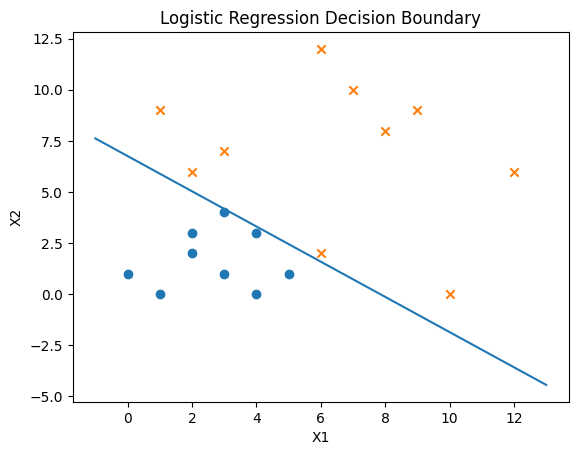

In [29]:

plt.figure()

plt.scatter(A["X1"], A["X2"], marker="o")
plt.scatter(B["X1"], B["X2"], marker="x")

x_values = np.linspace(data["X1"].min()-1, data["X1"].max()+1, 100)
x2_values = (-w[0] - w[1]*x_values) / w[2]

plt.plot(x_values, x2_values)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Logistic Regression Decision Boundary")

plt.show()